In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet(
    "../data/Divar_cleaned.parquet",
    columns=["jalali_year", "price_value"]
)

df.head()

,jalali_year,price_value
0,1403,NaN
1,1403,8.500000e+09
2,1403,NaN
3,1403,NaN
4,1403,5.750000e+09


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999997 entries, 0 to 999996
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   jalali_year  999997 non-null  Int64  
 1   price_value  568345 non-null  float64
dtypes: Int64(1), float64(1)
memory usage: 16.2 MB


In [6]:
analysis_df = df[
    df["jalali_year"].between(1400, 1403) &
    df["price_value"].notna()
].copy()

yearly_price = (
    analysis_df
    .groupby("jalali_year")
    .agg(
        observations=("price_value", "count"),
        nominal_mean_price=("price_value", "mean")
    )
    .reset_index()
)

yearly_price

,jalali_year,observations,nominal_mean_price
0,1400,3,1.066667e+09
1,1401,48,1.882049e+10
2,1402,4095,7.918916e+09
3,1403,564198,1.743386e+10


In [7]:
inflation_rates = {
    1401: 45.75,
    1402: 40.69,
    1403: 32.50
}

cpi = {
    1400: 100.0,
    1401: 100 * (1 + inflation_rates[1401] / 100)
}

cpi[1402] = cpi[1401] * (1 + inflation_rates[1402] / 100)
cpi[1403] = cpi[1402] * (1 + inflation_rates[1403] / 100)

yearly_price["cpi"] = yearly_price["jalali_year"].map(cpi)

yearly_price["real_mean_price"] = (
    yearly_price["nominal_mean_price"] * 100 / yearly_price["cpi"]
)

yearly_price["nominal_growth_pct"] = (
    yearly_price["nominal_mean_price"].pct_change() * 100
)

yearly_price["real_growth_pct"] = (
    yearly_price["real_mean_price"].pct_change() * 100
)

yearly_price

,jalali_year,observations,nominal_mean_price,cpi,real_mean_price,nominal_growth_pct,real_growth_pct
0,1400,3,1.066667e+09,100.000000,1.066667e+09,NaN,NaN
1,1401,48,1.882049e+10,145.750000,1.291285e+10,1664.420573,1110.580153
2,1402,4095,7.918916e+09,205.055675,3.861837e+09,-57.923957,-70.093082
3,1403,564198,1.743386e+10,271.698769,6.416614e+09,120.154651,66.154453


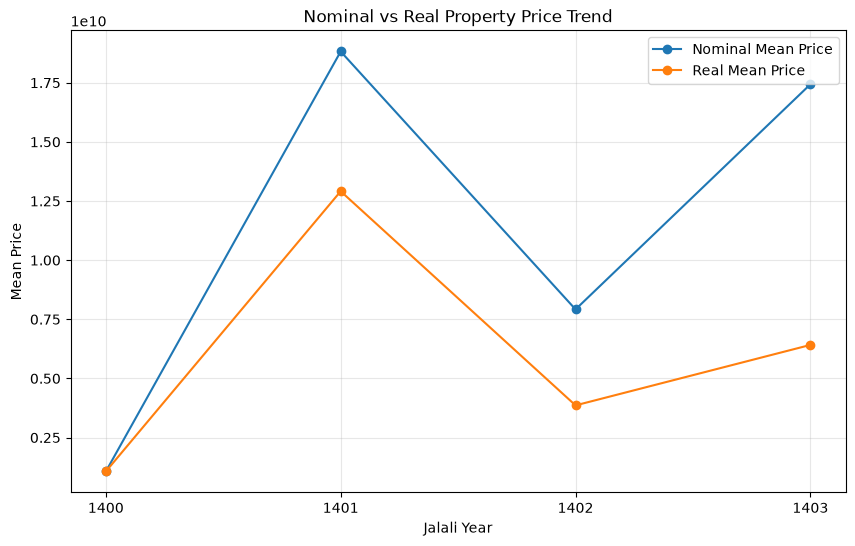

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_price["jalali_year"],
    yearly_price["nominal_mean_price"],
    marker="o",
    label="Nominal Mean Price"
)

plt.plot(
    yearly_price["jalali_year"],
    yearly_price["real_mean_price"],
    marker="o",
    label="Real Mean Price"
)

plt.xlabel("Jalali Year")
plt.ylabel("Mean Price")
plt.title("Nominal vs Real Property Price Trend")
plt.xticks([1400, 1401, 1402, 1403])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [9]:
## Conclusion

Nominal property prices do not directly represent changes in real property
value because part of their increase can be explained by inflation.

After adjusting the yearly mean `price_value` using the Consumer Price Index,
the real-price trend can be compared with the nominal-price trend.

A substantial difference between nominal and real price growth indicates that
part of the observed increase in property prices is attributable to inflation
rather than a proportional increase in real property value.

### Important limitation

The number of valid observations is highly unbalanced across years.
In particular, years 1400 and 1401 contain very few observations compared
with 1402 and 1403. Therefore, estimates for the early years should be
interpreted cautiously and should not be considered equally representative
of the housing market.

SyntaxError: invalid syntax (3194817229.py, line 3)